In [1]:
# ==============================
# 1. Data Handling
# ==============================
import numpy as np
import pandas as pd

# ==============================
# 2. Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 3. Machine Learning
# ==============================
from sklearn.model_selection import train_test_split

# Categorical & Numerical Encoding/Scaling
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

# Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
#load csv file
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df.info())
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

In [5]:
# Missing Values Check
print("Missing values:")
print(df.isnull().sum().sum())

print("\nEmpty strings:")
print((df.astype(str).apply(lambda x: x.str.strip() == "").sum().sum()))

Missing values:
0

Empty strings:
11


In [6]:
# Check for empty strings or spaces
(df.astype(str).apply(lambda x: x.str.strip() == "").sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
# Display the 11 rows with blank TotalCharges
blank_mask = df["TotalCharges"].astype(str).str.strip() == ""
print(f"Number of blank rows: {blank_mask.sum()}")
df[blank_mask]

Number of blank rows: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
# Count customers with tenure = 0
print(f"Number of customers with tenure = 0: {(df['tenure'] == 0).sum()}")
df[df['tenure'] == 0]

Number of customers with tenure = 0: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### Finding: The 11 blank rows are exactly the customers with tenure = 0

- Rows with blank `TotalCharges` (" "): **11**
- Customers with `tenure == 0`: **11**
- They are the exact same 11 customers (perfect overlap), all with `Churn = No` and mostly `Contract = Two year`.

**Interpretation:** These are brand-new customers (zero months with the company), so it is logical that their total amount charged `TotalCharges = 0` because they have not been billed yet, while their `MonthlyCharges` are valid (mean ~41.4).

**Decision:**
- Do NOT fill with the median (~1397), which reflects long-tenure customers and would distort the data.
- Do NOT drop the rows, since they are a real segment (new customers).
- Correct approach: fill the 11 blank values with `0` (equivalent to `tenure * MonthlyCharges = 0`).

In [9]:
# Fix TotalCharges: convert to numeric, then fill tenure=0 blanks with 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("NaNs before fix:", df["TotalCharges"].isnull().sum())

df.loc[df["tenure"] == 0, "TotalCharges"] = df.loc[df["tenure"] == 0, "TotalCharges"].fillna(0)

print("NaNs after fix:", df["TotalCharges"].isnull().sum())
print("TotalCharges dtype:", df["TotalCharges"].dtype)
df["TotalCharges"].describe()

NaNs before fix: 11
NaNs after fix: 0
TotalCharges dtype: float64


count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

## Pre-encoding checks: duplicates, outliers, types, distributions

In [10]:
# 1. Duplicates check (run on fresh df, before dropping customerID)
print("Duplicated rows:", df.duplicated().sum())
if "customerID" in df.columns:
    print("Duplicated customerID:", df["customerID"].duplicated().sum())
else:
    print("customerID already dropped — uniqueness was verified before the drop (0 duplicates).")
print("Shape:", df.shape)

Duplicated rows: 0
Duplicated customerID: 0
Shape: (7043, 21)


In [11]:
# 2. Numeric summary + IQR outlier check + skewness
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
print(df[num_cols + ["SeniorCitizen"]].describe().to_string())
print("\nSkewness:")
print(df[num_cols].skew().to_string())
print()
for c in num_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f"{c}: Q1={q1:.2f} Q3={q3:.2f} IQR={iqr:.2f} bounds=[{lo:.2f},{hi:.2f}] outliers={n_out} ({n_out/len(df)*100:.2f}%)")

            tenure  MonthlyCharges  TotalCharges  SeniorCitizen
count  7043.000000     7043.000000   7043.000000    7043.000000
mean     32.371149       64.761692   2279.734304       0.162147
std      24.559481       30.090047   2266.794470       0.368612
min       0.000000       18.250000      0.000000       0.000000
25%       9.000000       35.500000    398.550000       0.000000
50%      29.000000       70.350000   1394.550000       0.000000
75%      55.000000       89.850000   3786.600000       0.000000
max      72.000000      118.750000   8684.800000       1.000000

Skewness:
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.963235

tenure: Q1=9.00 Q3=55.00 IQR=46.00 bounds=[-60.00,124.00] outliers=0 (0.00%)
MonthlyCharges: Q1=35.50 Q3=89.85 IQR=54.35 bounds=[-46.02,171.38] outliers=0 (0.00%)
TotalCharges: Q1=398.55 Q3=3786.60 IQR=3388.05 bounds=[-4683.52,8868.67] outliers=0 (0.00%)


In [12]:
# 3. Categorical levels (Note: 'No internet service' / 'No phone service' are valid levels, not missing)
cat_cols = [c for c in df.columns if str(df[c].dtype) in ("object", "str", "string") and c not in ["customerID"]]
for c in cat_cols:
    print(f"== {c} ==")
    print(df[c].value_counts(dropna=False).to_string())
    print()

== gender ==
gender
Male      3555
Female    3488

== Partner ==
Partner
No     3641
Yes    3402

== Dependents ==
Dependents
No     4933
Yes    2110

== PhoneService ==
PhoneService
Yes    6361
No      682

== MultipleLines ==
MultipleLines
No                  3390
Yes                 2971
No phone service     682

== InternetService ==
InternetService
Fiber optic    3096
DSL            2421
No             1526

== OnlineSecurity ==
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526

== OnlineBackup ==
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526

== DeviceProtection ==
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526

== TechSupport ==
TechSupport
No                     3473
Yes                    2044
No internet service    1526

== StreamingTV ==
StreamingTV
No                     2810
Yes                    2707
No internet service

In [13]:
# 4. Target distribution + SeniorCitizen + customerID handling
print("Churn distribution:")
print(df["Churn"].value_counts().to_string())
print(df["Churn"].value_counts(normalize=True).round(4).to_string())
print()
print("SeniorCitizen (0/1 numeric but actually categorical):")
print(df["SeniorCitizen"].value_counts().to_string())
print()
print("customerID unique:", df["customerID"].nunique(), "/ rows:", len(df))

# Drop customerID: identifier with no predictive value
df = df.drop(columns=["customerID"])
print("Shape after dropping customerID:", df.shape)

Churn distribution:
Churn
No     5174
Yes    1869
Churn
No     0.7346
Yes    0.2654

SeniorCitizen (0/1 numeric but actually categorical):
SeniorCitizen
0    5901
1    1142

customerID unique: 7043 / rows: 7043
Shape after dropping customerID: (7043, 20)


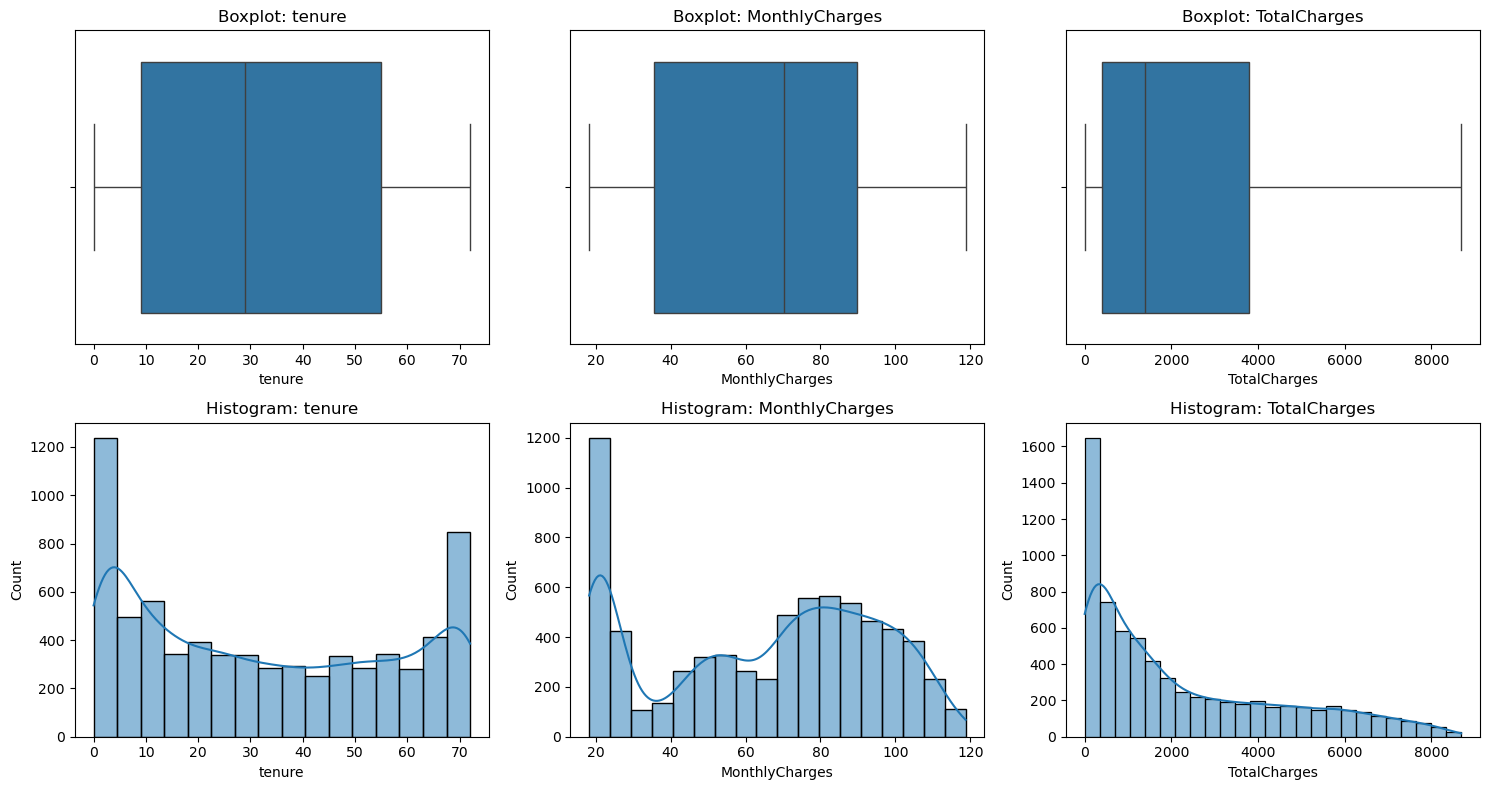

In [14]:
# 5. Visual check: boxplots + histograms for tenure / MonthlyCharges / TotalCharges
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, c in enumerate(["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(x=df[c], ax=axes[0, i])
    axes[0, i].set_title(f"Boxplot: {c}")
    sns.histplot(df[c], kde=True, ax=axes[1, i])
    axes[1, i].set_title(f"Histogram: {c}")
plt.tight_layout()
plt.show()

In [15]:
# Export end-state for the next levels
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/df_task1.csv", index=False)
print("Saved data/df_task1.csv:", df.shape)

Saved data/df_task1.csv: (7043, 20)
